# Dreamcash vs Tradexyz Tracking Analysis with `polaris_data`

This notebook uses `polaris-data>=0.8.4` to:

- discover the shared `dreamcash` and `tradexyz` markets in Polaris
- fetch a bounded day of 1-minute OHLCV data for a small shared ticker basket
- compare activity, return alignment, and price tracking quality across venues
- zoom into one focus ticker with raw trades and hourly notional plots


In [11]:
%pip install -U "polaris-data>=0.8.4" pandas matplotlib


/Users/hilliamtung/conductor/workspaces/polaris-notebooks/indianapolis-v2/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [12]:
from polaris_data import PolarisClient
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")
pd.options.display.float_format = "{:.4f}".format


In [13]:
source_a = "dreamcash"
source_b = "tradexyz"

# Use an explicit bounded range with polaris-data 0.8.4.
start = "2026-06-29T00:00:00Z"
end = "2026-06-30T00:00:00Z"

selected_tickers = ["GOLD", "NVDA", "AMZN", "TSLA", "MSFT"]
focus_ticker = "NVDA"


In [14]:
def normalize_market_id(market_id: str) -> str:
    market_id = market_id.upper()
    for prefix in ("CASH:", "XYZ:"):
        if market_id.startswith(prefix):
            return market_id[len(prefix):]
    return market_id


def bars_to_frame(bars: list[dict]) -> pd.DataFrame:
    frame = pd.DataFrame(bars)
    if frame.empty:
        return pd.DataFrame(columns=["open", "high", "low", "close", "volume", "trades", "interval"])

    frame["timestamp"] = pd.to_datetime(frame["timestamp"], unit="us", utc=True)
    return frame.set_index("timestamp").sort_index()


def trades_to_frame(trades: list[dict]) -> pd.DataFrame:
    frame = pd.json_normalize(trades)
    if frame.empty:
        return pd.DataFrame(columns=["timestamp", "price", "quantity", "side"])

    frame["timestamp"] = pd.to_datetime(frame["timestamp"], unit="us", utc=True)
    frame = frame.rename(
        columns={
            "data.price": "price",
            "data.quantity": "quantity",
            "data.side": "side",
        }
    )
    return frame[["timestamp", "price", "quantity", "side"]].sort_values("timestamp")


def regular_trading_hours_mask(index: pd.DatetimeIndex) -> pd.Series:
    local = index.tz_convert("America/New_York")
    is_weekday = local.dayofweek < 5
    after_open = (local.hour > 9) | ((local.hour == 9) & (local.minute >= 30))
    before_close = local.hour < 16
    return is_weekday & after_open & before_close


def catalog_markets_to_frame(catalog: dict) -> pd.DataFrame:
    if "markets" in catalog:
        frame = pd.DataFrame(catalog["markets"])
        if frame.empty:
            return pd.DataFrame(columns=["source", "market", "start", "end", "categories", "access", "source_type"])
        return frame

    if "sources" in catalog:
        rows = []
        for source_entry in catalog["sources"]:
            source_id = source_entry.get("id") or source_entry.get("source") or source_entry.get("name")
            for market_entry in source_entry.get("markets", []):
                rows.append(
                    {
                        "source": source_id,
                        "market": market_entry.get("market") or market_entry.get("id"),
                        "start": market_entry.get("start"),
                        "end": market_entry.get("end"),
                        "categories": market_entry.get("categories", []),
                        "access": market_entry.get("access", {}),
                        "source_type": market_entry.get("source_type") or market_entry.get("source"),
                    }
                )
        return pd.DataFrame(rows)

    raise KeyError("Catalog response did not include either 'markets' or 'sources'.")


In [15]:
with PolarisClient() as client:
    catalog = client.catalog()

catalog_markets = catalog_markets_to_frame(catalog)
catalog_markets = catalog_markets[catalog_markets["source"].isin([source_a, source_b])].copy()

shared_market_map = {}
for _, market in catalog_markets.iterrows():
    source_name = market["source"]
    ticker = normalize_market_id(market["market"])
    shared_market_map.setdefault(ticker, {})[source_name] = market["market"]

shared_market_map = {
    ticker: mapping
    for ticker, mapping in shared_market_map.items()
    if source_a in mapping and source_b in mapping
}

available_shared_tickers = sorted(shared_market_map)
missing_tickers = sorted(set(selected_tickers) - set(shared_market_map))
if missing_tickers:
    raise KeyError(f"Selected tickers missing shared markets: {missing_tickers}")

selected_market_map = {ticker: shared_market_map[ticker] for ticker in selected_tickers}

mapping_df = pd.DataFrame(
    [
        {
            "ticker": ticker,
            f"{source_a}_market": mapping[source_a],
            f"{source_b}_market": mapping[source_b],
        }
        for ticker, mapping in selected_market_map.items()
    ]
)

print(f"Shared markets discovered: {len(available_shared_tickers)}")
display(mapping_df)


Shared markets discovered: 11


,ticker,dreamcash_market,tradexyz_market
0,GOLD,cash:GOLD,xyz:GOLD
1,NVDA,cash:NVDA,xyz:NVDA
2,AMZN,cash:AMZN,xyz:AMZN
3,TSLA,cash:TSLA,xyz:TSLA
4,MSFT,cash:MSFT,xyz:MSFT


In [16]:
bars_by_ticker = {}

with PolarisClient() as client:
    for ticker, market_map in selected_market_map.items():
        bars_by_ticker[ticker] = {}
        for source_name, market_id in market_map.items():
            bars = client.ohlcv(
                source=source_name,
                market=market_id,
                interval="1m",
                from_=start,
                to=end,
            )
            bars_by_ticker[ticker][source_name] = bars_to_frame(bars)

activity_rows = []
tracking_rows = []

for ticker, pair in bars_by_ticker.items():
    for source_name, frame in pair.items():
        activity_rows.append(
            {
                "ticker": ticker,
                "source": source_name,
                "active_minutes": int(len(frame)),
                "trade_count": int(frame["trades"].sum()) if not frame.empty else 0,
                "volume": float(frame["volume"].sum()) if not frame.empty else 0.0,
                "first_close": float(frame["close"].iloc[0]) if not frame.empty else None,
                "last_close": float(frame["close"].iloc[-1]) if not frame.empty else None,
                "return_pct": float((frame["close"].iloc[-1] / frame["close"].iloc[0] - 1.0) * 100) if len(frame) > 1 else None,
            }
        )

    merged = pair[source_a][["close", "volume", "trades"]].rename(
        columns={
            "close": f"{source_a}_close",
            "volume": f"{source_a}_volume",
            "trades": f"{source_a}_trades",
        }
    ).join(
        pair[source_b][["close", "volume", "trades"]].rename(
            columns={
                "close": f"{source_b}_close",
                "volume": f"{source_b}_volume",
                "trades": f"{source_b}_trades",
            }
        ),
        how="inner",
    )
    merged["spread_bps"] = (merged[f"{source_a}_close"] / merged[f"{source_b}_close"] - 1.0) * 10000

    trade_total = merged[f"{source_a}_trades"].sum() + merged[f"{source_b}_trades"].sum()
    tracking_rows.append(
        {
            "ticker": ticker,
            "overlap_minutes": int(len(merged)),
            "close_corr": float(merged[f"{source_a}_close"].corr(merged[f"{source_b}_close"])) if len(merged) > 1 else None,
            "mean_abs_spread_bps": float(merged["spread_bps"].abs().mean()) if len(merged) else None,
            "max_abs_spread_bps": float(merged["spread_bps"].abs().max()) if len(merged) else None,
            f"{source_a}_share_of_trades": float(merged[f"{source_a}_trades"].sum() / trade_total) if trade_total else None,
        }
    )

activity_summary = pd.DataFrame(activity_rows).sort_values(["ticker", "source"]).reset_index(drop=True)
tracking_metrics = pd.DataFrame(tracking_rows).set_index("ticker").sort_values("mean_abs_spread_bps")

display(activity_summary)
display(tracking_metrics)


,ticker,source,active_minutes,trade_count,volume,first_close,last_close,return_pct
0,AMZN,dreamcash,118,843,6355.5190,234.6200,241.4600,2.9154
1,AMZN,tradexyz,1092,10887,63276.4450,233.4200,240.7100,3.1231
2,GOLD,dreamcash,95,830,353.6205,4066.7000,4030.4000,-0.8926
3,GOLD,tradexyz,1435,16854,7233.7814,4061.0000,4019.2000,-1.0293
4,MSFT,dreamcash,53,388,793.6830,376.6700,371.4900,-1.3752
5,MSFT,tradexyz,1236,16951,90339.6340,377.0700,371.6100,-1.4480
6,NVDA,dreamcash,88,678,1899.8670,194.3700,195.3300,0.4939
7,NVDA,tradexyz,1336,20960,151518.5210,194.1900,195.3000,0.5716
8,TSLA,dreamcash,172,843,2623.1280,382.3300,409.2900,7.0515
9,TSLA,tradexyz,1256,17535,60348.8040,381.8000,408.7400,7.0561


,overlap_minutes,close_corr,mean_abs_spread_bps,max_abs_spread_bps,dreamcash_share_of_trades
ticker,,,,,
MSFT,53,0.9940,11.9220,34.4892,0.1857
GOLD,95,0.9888,13.5189,35.1946,0.3222
TSLA,164,0.9997,14.5324,32.1122,0.1328
NVDA,87,0.9842,16.3577,48.4961,0.1687
AMZN,115,0.9974,23.2325,45.7472,0.2919


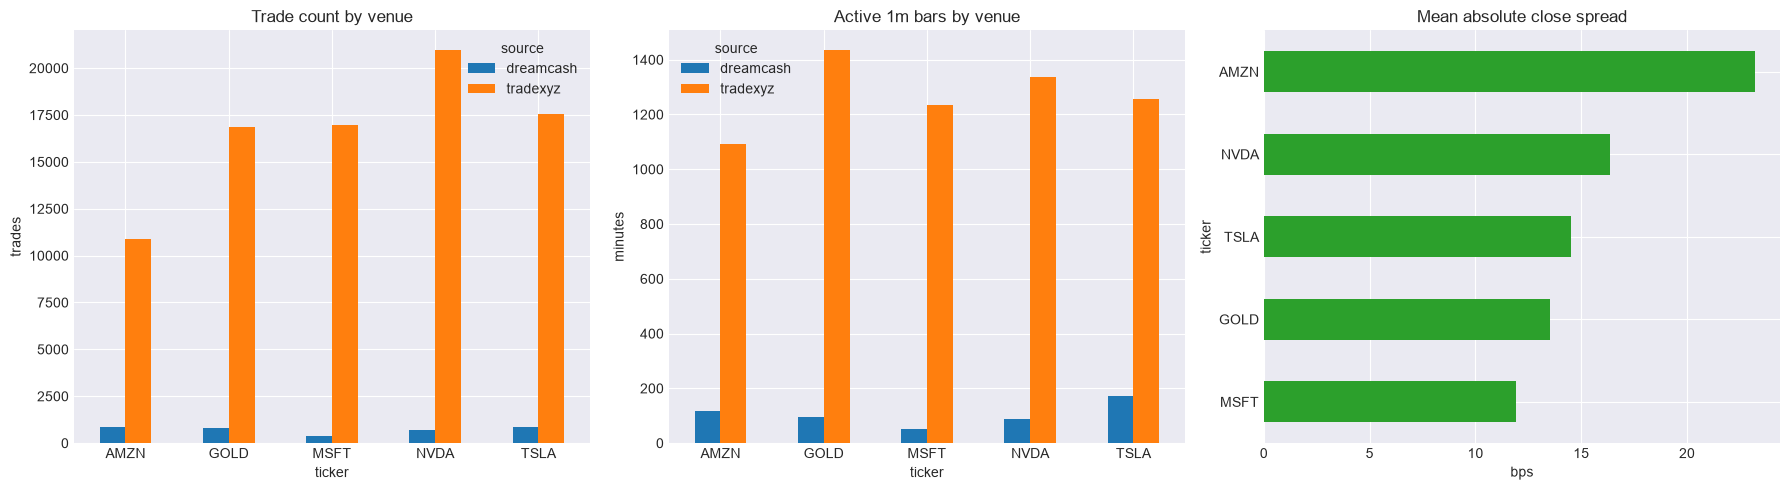

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

activity_summary.pivot(index="ticker", columns="source", values="trade_count").plot(
    kind="bar",
    ax=axes[0],
    title="Trade count by venue",
)
axes[0].set_ylabel("trades")
axes[0].tick_params(axis="x", rotation=0)

activity_summary.pivot(index="ticker", columns="source", values="active_minutes").plot(
    kind="bar",
    ax=axes[1],
    title="Active 1m bars by venue",
)
axes[1].set_ylabel("minutes")
axes[1].tick_params(axis="x", rotation=0)

tracking_metrics["mean_abs_spread_bps"].sort_values().plot(
    kind="barh",
    ax=axes[2],
    title="Mean absolute close spread",
    color="C2",
)
axes[2].set_xlabel("bps")

plt.tight_layout()


,dreamcash_close,dreamcash_volume,dreamcash_trades,tradexyz_close,tradexyz_volume,tradexyz_trades,spread_bps
timestamp,,,,,,,
2026-06-29 13:55:00+00:00,194.7700,7.6750,5,193.8300,705.5010,66,48.4961
2026-06-29 13:30:00+00:00,193.7400,73.9840,14,192.9400,1694.2680,250,41.4637
2026-06-29 00:01:00+00:00,194.5800,131.1300,8,193.8600,1866.7460,128,37.1402
2026-06-29 14:22:00+00:00,192.0300,26.4050,5,191.4400,1618.4910,82,30.8191
2026-06-29 05:00:00+00:00,193.9800,1.3080,3,193.4200,50.2980,42,28.9525
2026-06-29 13:56:00+00:00,193.9900,22.9550,10,193.4300,546.2950,59,28.9510
2026-06-29 14:47:00+00:00,194.4900,26.2640,8,193.9300,127.0140,14,28.8764
2026-06-29 06:38:00+00:00,195.2700,1.0860,3,194.7800,50.3620,11,25.1566
2026-06-29 00:05:00+00:00,193.8400,15.0450,3,193.3600,620.1050,97,24.8242


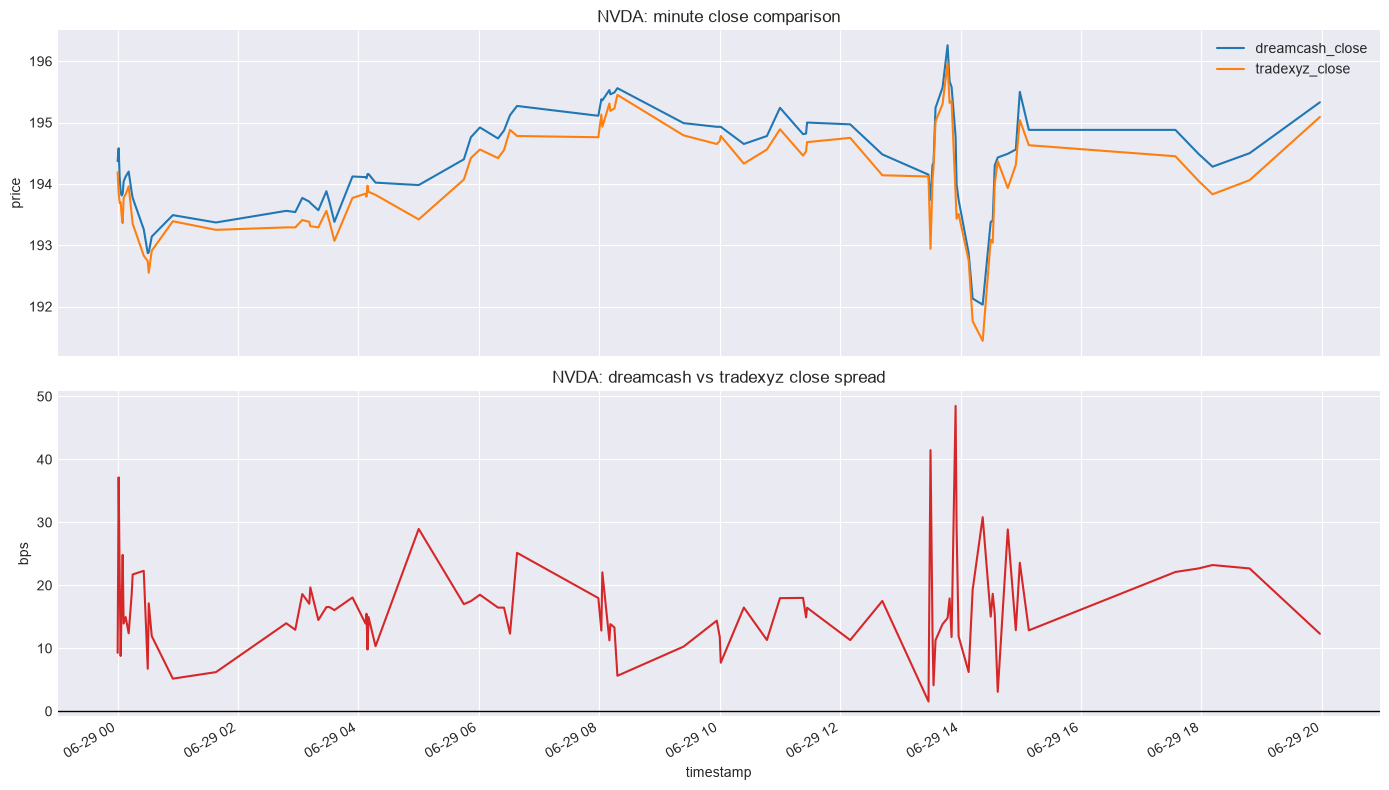

In [18]:
focus_pair = bars_by_ticker[focus_ticker]
focus_merged = focus_pair[source_a][["close", "volume", "trades"]].rename(
    columns={
        "close": f"{source_a}_close",
        "volume": f"{source_a}_volume",
        "trades": f"{source_a}_trades",
    }
).join(
    focus_pair[source_b][["close", "volume", "trades"]].rename(
        columns={
            "close": f"{source_b}_close",
            "volume": f"{source_b}_volume",
            "trades": f"{source_b}_trades",
        }
    ),
    how="inner",
)
focus_merged["spread_bps"] = (focus_merged[f"{source_a}_close"] / focus_merged[f"{source_b}_close"] - 1.0) * 10000

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
focus_merged[[f"{source_a}_close", f"{source_b}_close"]].plot(
    ax=axes[0],
    title=f"{focus_ticker}: minute close comparison",
)
axes[0].set_ylabel("price")

focus_merged["spread_bps"].plot(
    ax=axes[1],
    color="C3",
    title=f"{focus_ticker}: {source_a} vs {source_b} close spread",
)
axes[1].axhline(0.0, color="black", linewidth=1.0)
axes[1].set_ylabel("bps")
axes[1].set_xlabel("timestamp")

plt.tight_layout()

focus_merged.sort_values("spread_bps", key=lambda s: s.abs(), ascending=False).head(10)


In [19]:
with PolarisClient() as client:
    focus_trades = {}
    for source_name, market_id in selected_market_map[focus_ticker].items():
        trades = client.trades(
            source=source_name,
            market=market_id,
            from_=start,
            to=end,
        )
        focus_trades[source_name] = trades_to_frame(trades)

trade_summary_rows = []
hourly_notional = {}

for source_name, frame in focus_trades.items():
    trade_count = len(frame)
    notional = frame["price"] * frame["quantity"] if trade_count else pd.Series(dtype=float)
    indexed = frame.set_index("timestamp") if trade_count else frame.copy()

    if trade_count:
        indexed["notional"] = indexed["price"] * indexed["quantity"]
        hourly_notional[source_name] = indexed["notional"].resample("1h").sum()
        rth_mask = regular_trading_hours_mask(indexed.index)
        rth_trade_share = float(indexed.loc[rth_mask].shape[0] / trade_count)
        rth_notional_share = float(indexed.loc[rth_mask, "notional"].sum() / indexed["notional"].sum())
    else:
        hourly_notional[source_name] = pd.Series(dtype=float)
        rth_trade_share = None
        rth_notional_share = None

    trade_summary_rows.append(
        {
            "source": source_name,
            "trade_count": int(trade_count),
            "buy_volume": float(frame.loc[frame["side"] == "buy", "quantity"].sum()) if trade_count else 0.0,
            "sell_volume": float(frame.loc[frame["side"] == "sell", "quantity"].sum()) if trade_count else 0.0,
            "notional_usd": float(notional.sum()) if trade_count else 0.0,
            "rth_trade_share": rth_trade_share,
            "rth_notional_share": rth_notional_share,
        }
    )

focus_trade_summary = pd.DataFrame(trade_summary_rows).set_index("source")
display(focus_trade_summary)


,trade_count,buy_volume,sell_volume,notional_usd,rth_trade_share,rth_notional_share
source,,,,,,
dreamcash,678,724.6230,1175.2440,368848.7415,0.2227,0.2828
tradexyz,20960,72954.3680,78564.1530,29387804.1511,0.5286,0.6096


dreamcash


,timestamp,price,quantity,side
0,2026-06-29 00:00:02.912000+00:00,194.8900,8.4580,sell
1,2026-06-29 00:00:03.378000+00:00,194.8700,1.0160,sell
2,2026-06-29 00:00:03.654000+00:00,194.8700,1.0160,sell
3,2026-06-29 00:00:04.020000+00:00,194.8700,1.0160,sell
4,2026-06-29 00:00:04.092000+00:00,194.8700,1.0160,sell


tradexyz


,timestamp,price,quantity,side
0,2026-06-29 00:00:00.671000+00:00,195.0900,4.6400,buy
27,2026-06-29 00:00:02.107000+00:00,194.6600,4.9320,sell
26,2026-06-29 00:00:02.107000+00:00,194.6600,34.7210,sell
25,2026-06-29 00:00:02.107000+00:00,194.7400,26.2690,sell
24,2026-06-29 00:00:02.107000+00:00,194.8000,39.6250,sell


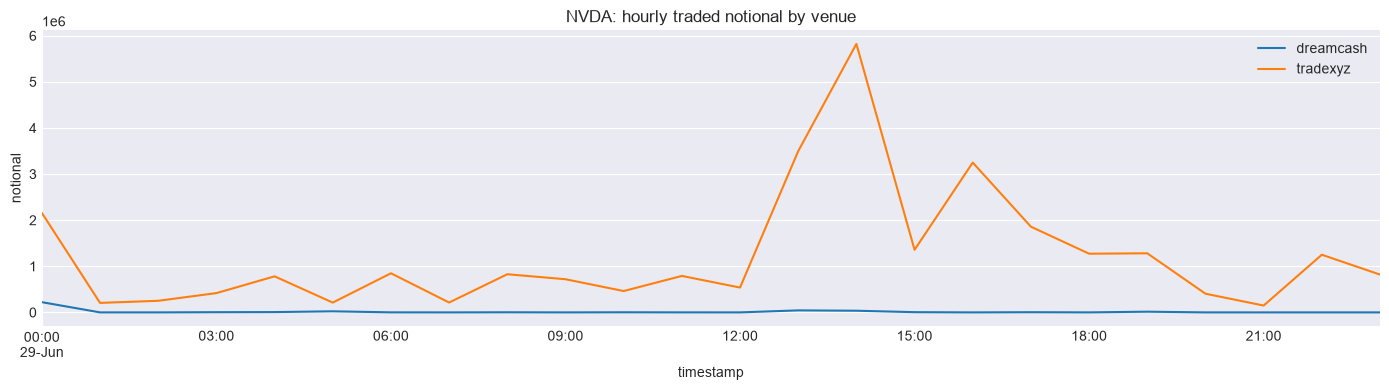

In [20]:
hourly_notional_df = pd.DataFrame(hourly_notional).fillna(0.0)
ax = hourly_notional_df.plot(
    figsize=(14, 4),
    title=f"{focus_ticker}: hourly traded notional by venue",
)
ax.set_ylabel("notional")
ax.set_xlabel("timestamp")
plt.tight_layout()

for source_name, frame in focus_trades.items():
    print(source_name)
    display(frame.head())


## Notes

- `dreamcash` is much sparser than `tradexyz`, so overlap and spread metrics are driven by the minutes where both venues print prices.
- `tradexyz` behaves like the denser reference market in this notebook, while `dreamcash` is useful for measuring tracking quality and activity concentration.
- To turn this into a wider market scan, expand `selected_tickers` or rank the full shared universe by `mean_abs_spread_bps` and `trade_count`.
